In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import time
import datetime
import yaml
import json

import torch
from torch.utils.data import Dataset, DataLoader, RandomSampler
from torchvision.transforms import v2
from torchvision.io import decode_image
from torchvision.models import resnet50

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import src.analysis

#####

with open("config/common.yaml", "r") as common_params:
    common = yaml.safe_load(common_params)
    # unpack params
    conditions = common["conditions"]
    class_cols = common["class_cols"]
    n_classes = common["n_classes"]
    n_class_values = common["n_class_values"]

pred_cols = [col + "_pred" for col in class_cols]
confidence_cols = [col + "_confidence" for col in class_cols]

# Analyzing Model Results

This notebook is split into two sections:

* The first section shows the results of a single model
* The second section shows the results for multiple models (The results file paths *must* exist)

### Analyzing Results for a Single Model

In [2]:
analyze_single_model = False

if analyze_single_model:
    # Edit the result filepath here
    results_file_paths = dict(
        model = "results/ResNet50_BASE224_test_withPredictionsAndConfidences.csv"
    )
    # Set include_certain_vs_uncertain if that analysis should be included
    include_certain_vs_uncertain0 = True
    
    #####
    results = scripts.analysis.get_all_metrics(results_file_paths, include_certain_vs_uncertain=include_certain_vs_uncertain0)

    # Convert dictionary to data frame
    results_df = scripts.analysis.results_to_df(dict(model=results))

    # Save results
    with open("results/model_metrics/single_model_metrics.json", "w") as fh:
        json.dump(results, fh)
    results_df.to_csv("results/model_metrics/single_model_metrics.csv", index=False)

### Analyzing Results for Multiple Models

To view results for multiple models, make sure the corresponding file path below is activated. Comment out any model file paths that should not be included in the analysis.

In [3]:
### Get metrics for test results
test_results_file_paths = dict(
    resnet_base224 = "results/ResNet50_BASE224_test_withPredictionsAndConfidences.csv",
    resnet_base224_enhanced = "results/ResNet50_BASE224_ENHANCED_test_withPredictionsAndConfidences.csv",
    densenet_base224 = "results/DenseNet121_BASE224_test_withPredictionsAndConfidences.csv",
    densenet_base224_enhanced = "results/DenseNet121_BASE224_ENHANCED_test_withPredictionsAndConfidences.csv",
    #
    resnet_base384 = "results/ResNet50_BASE384_test_withPredictionsAndConfidences.csv",
    resnet_base384_enhanced = "results/ResNet50_BASE384_ENHANCED_test_withPredictionsAndConfidences.csv",
    densenet_base384 = "results/DenseNet121_BASE384_test_withPredictionsAndConfidences.csv",
    densenet_base384_enhanced = "results/DenseNet121_BASE384_ENHANCED_test_withPredictionsAndConfidences.csv",
    #
    resnet_base512 = "results/ResNet50_BASE512_test_withPredictionsAndConfidences.csv",
    resnet_base512_enhanced = "results/ResNet50_BASE512_ENHANCED_test_withPredictionsAndConfidences.csv",
    densenet_base512 = "results/DenseNet121_BASE512_test_withPredictionsAndConfidences.csv",
    densenet_base512_enhanced = "results/DenseNet121_BASE512_ENHANCED_test_withPredictionsAndConfidences.csv"
)

test_results = src.analysis.get_all_metrics(test_results_file_paths, include_certain_vs_uncertain=True)
    

These models will be analyzed:
    resnet_base224
    resnet_base224_enhanced
    densenet_base224
    densenet_base224_enhanced
    resnet_base384
    resnet_base384_enhanced
    densenet_base384
    densenet_base384_enhanced
    resnet_base512
    resnet_base512_enhanced
    densenet_base512
    densenet_base512_enhanced


In [4]:
### Get metrics for radiologist-labeled validation results
valid_rad_results_file_paths = dict(
    resnet_base224 = "results/ResNet50_BASE224_valid_rad_withPredictionsAndConfidences.csv",
    resnet_base224_enhanced = "results/ResNet50_BASE224_ENHANCED_valid_rad_withPredictionsAndConfidences.csv",
    densenet_base224 = "results/DenseNet121_BASE224_valid_rad_withPredictionsAndConfidences.csv",
    densenet_base224_enhanced = "results/DenseNet121_BASE224_ENHANCED_valid_rad_withPredictionsAndConfidences.csv",
    #
    resnet_base384 = "results/ResNet50_BASE384_valid_rad_withPredictionsAndConfidences.csv",
    resnet_base384_enhanced = "results/ResNet50_BASE384_ENHANCED_valid_rad_withPredictionsAndConfidences.csv",
    densenet_base384 = "results/DenseNet121_BASE384_valid_rad_withPredictionsAndConfidences.csv",
    densenet_base384_enhanced = "results/DenseNet121_BASE384_ENHANCED_valid_rad_withPredictionsAndConfidences.csv",
    #
    resnet_base512 = "results/ResNet50_BASE512_valid_rad_withPredictionsAndConfidences.csv",
    resnet_base512_enhanced = "results/ResNet50_BASE512_ENHANCED_valid_rad_withPredictionsAndConfidences.csv",
    densenet_base512 = "results/DenseNet121_BASE512_valid_rad_withPredictionsAndConfidences.csv",
    densenet_base512_enhanced = "results/DenseNet121_BASE512_ENHANCED_valid_rad_withPredictionsAndConfidences.csv"
)

valid_rad_results = src.analysis.get_all_metrics(valid_rad_results_file_paths, include_certain_vs_uncertain=False)
    

These models will be analyzed:
    resnet_base224
    resnet_base224_enhanced
    densenet_base224
    densenet_base224_enhanced
    resnet_base384
    resnet_base384_enhanced
    densenet_base384
    densenet_base384_enhanced
    resnet_base512
    resnet_base512_enhanced
    densenet_base512
    densenet_base512_enhanced


In [5]:
### Get metrics for radiologist-labeled validation results
test_rad_results_file_paths = dict(
    resnet_base224 = "results/ResNet50_BASE224_test_rad_withPredictionsAndConfidences.csv",
    resnet_base224_enhanced = "results/ResNet50_BASE224_ENHANCED_test_rad_withPredictionsAndConfidences.csv",
    densenet_base224 = "results/DenseNet121_BASE224_test_rad_withPredictionsAndConfidences.csv",
    densenet_base224_enhanced = "results/DenseNet121_BASE224_ENHANCED_test_rad_withPredictionsAndConfidences.csv",
    #
    resnet_base384 = "results/ResNet50_BASE384_test_rad_withPredictionsAndConfidences.csv",
    resnet_base384_enhanced = "results/ResNet50_BASE384_ENHANCED_test_rad_withPredictionsAndConfidences.csv",
    densenet_base384 = "results/DenseNet121_BASE384_test_withPredictionsAndConfidences.csv",
    densenet_base384_enhanced = "results/DenseNet121_BASE384_ENHANCED_test_rad_withPredictionsAndConfidences.csv",
    #
    resnet_base512 = "results/ResNet50_BASE512_test_rad_withPredictionsAndConfidences.csv",
    resnet_base512_enhanced = "results/ResNet50_BASE512_ENHANCED_test_rad_withPredictionsAndConfidences.csv",
    densenet_base512 = "results/DenseNet121_BASE512_test_rad_withPredictionsAndConfidences.csv",
    densenet_base512_enhanced = "results/DenseNet121_BASE512_ENHANCED_test_rad_withPredictionsAndConfidences.csv"
)

test_rad_results = src.analysis.get_all_metrics(test_rad_results_file_paths, include_certain_vs_uncertain=False)
    

These models will be analyzed:
    resnet_base224
    resnet_base224_enhanced
    densenet_base224
    densenet_base224_enhanced
    resnet_base384
    resnet_base384_enhanced
    densenet_base384
    densenet_base384_enhanced
    resnet_base512
    resnet_base512_enhanced
    densenet_base512
    densenet_base512_enhanced


In [6]:
results = dict(
    test_results=test_results,
    valid_rad_results=valid_rad_results,
    test_rad_results=test_rad_results
)

In [7]:
### Navigating the dictionary
for results_df_name,results_df in results.items():
    """
    At this level, choose the data frame being analyzed 
    (
    test_results, test_rad_results, valid_rad_results
    )
    """
    for model_name,model in results[results_df_name].items():
        """
        At this level choose the specific model configuration being analyzed
        (
        resnet_base224, resnet_base384, resnet_base512,
        densenet_base224, densenet_base384, densenet_base512,
        resnet_base224_enhanced, resnet_base384_enhanced, resnet_base512_enhanced,
        densenet_base224_enhanced, densenet_base384_enhanced, densenet_base512_enhanced
        )
        """
        for metric_category,metrics in results[results_df_name][model_name].items():
            """
            At this level, choose the specific category the metrics are applied to
            (
            positive_vs_negative
            certain_vs_uncertain (optional)
            )
            """
            for condition,cond_metrics in results[results_df_name][model_name][metric_category].items():
                """
                At this level, choose the specific condition being analyzed
                (
                Cardiomegaly, Consolidation, Edema, Atelectasis, Pleural Effusion
                )
                """
                for metric,value in results[results_df_name][model_name][metric_category][condition].items():
                    """
                    At this level, choose the specific metric to view
                    (
                    TP, FP, FN, TN,
                    TPR, FPR, FNR, TNR,
                    Precision, Recall,
                    BER, F1 Score
                    )
                    """
                    pass

# Example:
print(results["test_results"]["resnet_base224"]["positive_vs_negative"]["Cardiomegaly"]["TP"])

1080.0


In [8]:
### Saving results

### Save dictionary in json format
with open("results/model_metrics/model_metrics.json", "w") as fh:
    json.dump(results, fh)

### Converting the dictionary to data frame
results_df = src.analysis.results_to_df(results)
#
results_df.to_csv("results/model_metrics/model_metrics.csv", index=False)
results_df.head(10)

,results_df_name,model_name,metric_category,condition,metric,value
0,test_results,resnet_base224,positive_vs_negative,Cardiomegaly,TP,1080.000000
1,test_results,resnet_base224,positive_vs_negative,Cardiomegaly,FP,4140.000000
2,test_results,resnet_base224,positive_vs_negative,Cardiomegaly,FN,3680.000000
3,test_results,resnet_base224,positive_vs_negative,Cardiomegaly,TN,30471.000000
4,test_results,resnet_base224,positive_vs_negative,Cardiomegaly,TPR,0.226891
5,test_results,resnet_base224,positive_vs_negative,Cardiomegaly,FPR,0.119615
6,test_results,resnet_base224,positive_vs_negative,Cardiomegaly,FNR,0.773109
7,test_results,resnet_base224,positive_vs_negative,Cardiomegaly,TNR,0.880385
8,test_results,resnet_base224,positive_vs_negative,Cardiomegaly,Precision,0.207048
9,test_results,resnet_base224,positive_vs_negative,Cardiomegaly,Recall,0.227053


In [9]:
results_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2820 entries, 0 to 2819
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   results_df_name  2820 non-null   object 
 1   model_name       2820 non-null   object 
 2   metric_category  2820 non-null   object 
 3   condition        2820 non-null   object 
 4   metric           2820 non-null   object 
 5   value            2819 non-null   float64
dtypes: float64(1), object(5)
memory usage: 132.3+ KB


### Certain vs Uncertain

In [10]:
### Create palette
byModel_palette = {name:color for name,color in zip(results_df.model_name.unique(),
                                                    sns.color_palette(
                                                        palette="tab10", 
                                                        n_colors=len(results_df.model_name.unique())
                                                    )
                                                   )
                  }
print(byModel_palette)

{'resnet_base224': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765), 'resnet_base224_enhanced': (1.0, 0.4980392156862745, 0.054901960784313725), 'densenet_base224': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313), 'densenet_base224_enhanced': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392), 'resnet_base384': (0.5803921568627451, 0.403921568627451, 0.7411764705882353), 'resnet_base384_enhanced': (0.5490196078431373, 0.33725490196078434, 0.29411764705882354), 'densenet_base384': (0.8901960784313725, 0.4666666666666667, 0.7607843137254902), 'densenet_base384_enhanced': (0.4980392156862745, 0.4980392156862745, 0.4980392156862745), 'resnet_base512': (0.7372549019607844, 0.7411764705882353, 0.13333333333333333), 'resnet_base512_enhanced': (0.09019607843137255, 0.7450980392156863, 0.8117647058823529), 'densenet_base512': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765), 'densenet_base512_enhanced': (1.0, 0.4980392156862745, 0.054901960784

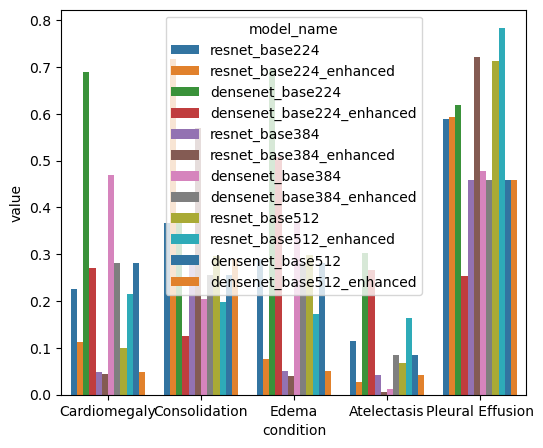

In [11]:
### Plotting TPR across models, one subplot per condition
df_filter = (
    (results_df.results_df_name=="test_results") & \
    (results_df.metric_category=="positive_vs_negative") & \
    (results_df.metric=="TPR")
)
plot_df = results_df.loc[df_filter, :]
###

fig,ax = plt.subplots(1,1, figsize=(6,5))

sns.barplot(data=plot_df, x="condition", y="value", hue="model_name", palette=byModel_palette, ax=ax)

plt.show()

In [12]:
results_df.loc[results_df.metric_category=="certain_vs_uncertain",:]

,results_df_name,model_name,metric_category,condition,metric,value
60,test_results,resnet_base224,certain_vs_uncertain,Cardiomegaly,TPU,0.338257
61,test_results,resnet_base224,certain_vs_uncertain,Cardiomegaly,FPU,2.853709
62,test_results,resnet_base224,certain_vs_uncertain,Cardiomegaly,FNU,0.661743
63,test_results,resnet_base224,certain_vs_uncertain,Cardiomegaly,TNU,0.512638
64,test_results,resnet_base224,certain_vs_uncertain,Cardiomegaly,FPU_AP,2.565731
...,...,...,...,...,...,...
1375,test_results,densenet_base512_enhanced,certain_vs_uncertain,Pleural Effusion,TNU_AP,0.177369
1376,test_results,densenet_base512_enhanced,certain_vs_uncertain,Pleural Effusion,TNU_AN,0.368980
1377,test_results,densenet_base512_enhanced,certain_vs_uncertain,Pleural Effusion,prec,0.374320
1378,test_results,densenet_base512_enhanced,certain_vs_uncertain,Pleural Effusion,recall,0.615076


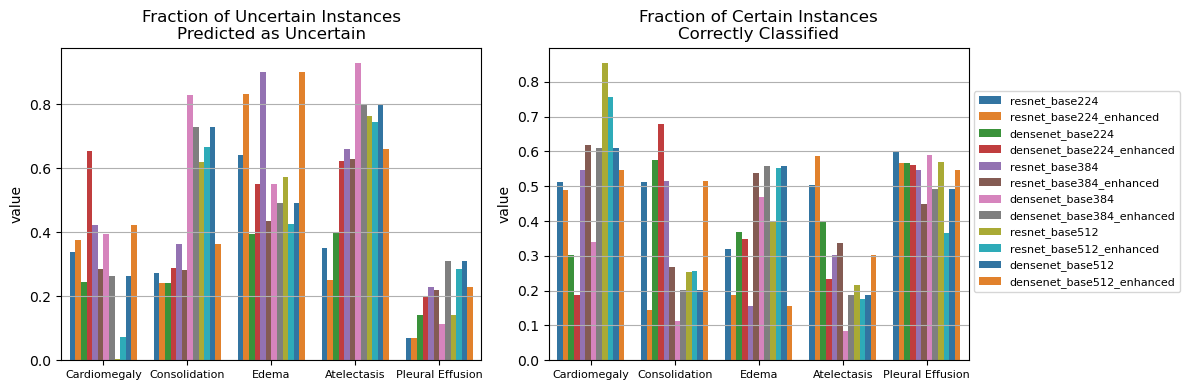

In [24]:
### Plotting TPR across models, one subplot per condition
fig,ax = plt.subplots(1,2, figsize=(12,4))
###

metric = "TPU"
df_filter = (
    (results_df.results_df_name=="test_results") & \
    (results_df.metric_category=="certain_vs_uncertain") & \
    (results_df.metric==metric)
)
plot_df = results_df.loc[df_filter, :]
#
sns.barplot(data=plot_df, x="condition", y="value", hue="model_name", palette=byModel_palette, ax=ax[0])
ax[0].set_xlabel("")
ax[0].set_title("Fraction of Uncertain Instances\nPredicted as Uncertain")
ax[0].xaxis.set_tick_params(labelsize=8)
ax[0].grid(axis="y")
ax[0].get_legend().remove()

metric = "TNU"
df_filter = (
    (results_df.results_df_name=="test_results") & \
    (results_df.metric_category=="certain_vs_uncertain") & \
    (results_df.metric==metric)
)
plot_df = results_df.loc[df_filter, :]
#
sns.barplot(data=plot_df, x="condition", y="value", hue="model_name", palette=byModel_palette, ax=ax[1])
ax[1].set_xlabel("")
ax[1].set_title("Fraction of Certain Instances\nCorrectly Classified")
ax[1].xaxis.set_tick_params(labelsize=8)
ax[1].grid(axis="y")
ax[1].legend(loc="lower left", bbox_to_anchor=(1,0.2), fontsize=8)

plt.tight_layout()
plt.show()

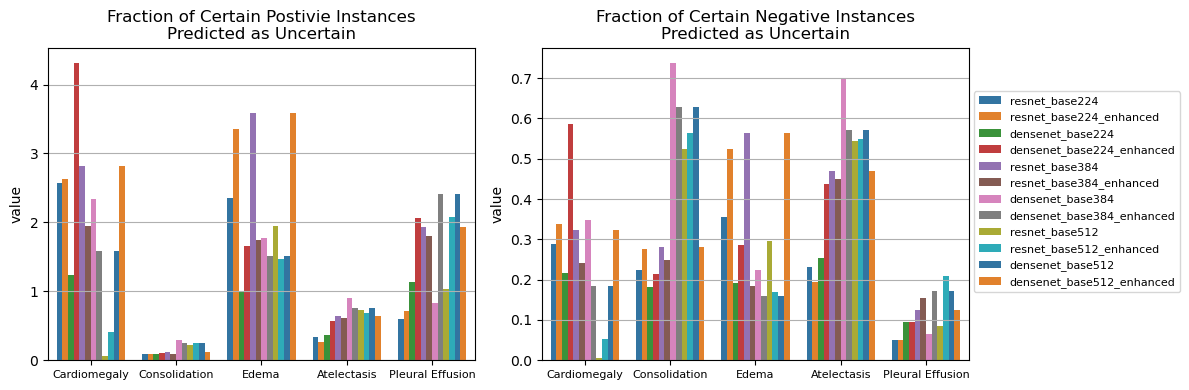

In [25]:
### Plotting TPR across models, one subplot per condition
fig,ax = plt.subplots(1,2, figsize=(12,4))
###

metric = "FPU_AP"
df_filter = (
    (results_df.results_df_name=="test_results") & \
    (results_df.metric_category=="certain_vs_uncertain") & \
    (results_df.metric==metric)
)
plot_df = results_df.loc[df_filter, :]
#
sns.barplot(data=plot_df, x="condition", y="value", hue="model_name", palette=byModel_palette, ax=ax[0])
ax[0].set_xlabel("")
ax[0].set_title("Fraction of Certain Postivie Instances\nPredicted as Uncertain")
ax[0].xaxis.set_tick_params(labelsize=8)
ax[0].grid(axis="y")
ax[0].get_legend().remove()

metric = "FPU_AN"
df_filter = (
    (results_df.results_df_name=="test_results") & \
    (results_df.metric_category=="certain_vs_uncertain") & \
    (results_df.metric==metric)
)
plot_df = results_df.loc[df_filter, :]
#
sns.barplot(data=plot_df, x="condition", y="value", hue="model_name", palette=byModel_palette, ax=ax[1])
ax[1].set_xlabel("")
ax[1].set_title("Fraction of Certain Negative Instances\nPredicted as Uncertain")
ax[1].xaxis.set_tick_params(labelsize=8)
ax[1].grid(axis="y")
ax[1].legend(loc="lower left", bbox_to_anchor=(1,0.2), fontsize=8)

plt.tight_layout()
plt.show()

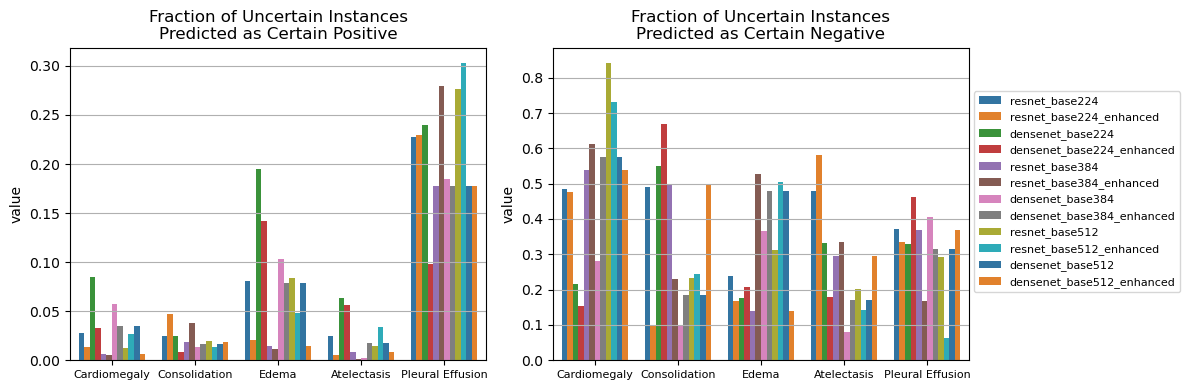

In [26]:
### Plotting TPR across models, one subplot per condition
fig,ax = plt.subplots(1,2, figsize=(12,4))
###

metric = "TNU_AP"
df_filter = (
    (results_df.results_df_name=="test_results") & \
    (results_df.metric_category=="certain_vs_uncertain") & \
    (results_df.metric==metric)
)
plot_df = results_df.loc[df_filter, :]
#
sns.barplot(data=plot_df, x="condition", y="value", hue="model_name", palette=byModel_palette, ax=ax[0])
ax[0].set_xlabel("")
ax[0].set_title("Fraction of Uncertain Instances\nPredicted as Certain Positive")
ax[0].xaxis.set_tick_params(labelsize=8)
ax[0].grid(axis="y")
ax[0].get_legend().remove()

metric = "TNU_AN"
df_filter = (
    (results_df.results_df_name=="test_results") & \
    (results_df.metric_category=="certain_vs_uncertain") & \
    (results_df.metric==metric)
)
plot_df = results_df.loc[df_filter, :]
#
sns.barplot(data=plot_df, x="condition", y="value", hue="model_name", palette=byModel_palette, ax=ax[1])
ax[1].set_xlabel("")
ax[1].set_title("Fraction of Uncertain Instances\nPredicted as Certain Negative")
ax[1].xaxis.set_tick_params(labelsize=8)
ax[1].grid(axis="y")
ax[1].legend(loc="lower left", bbox_to_anchor=(1,0.2), fontsize=8)

plt.tight_layout()
plt.show()

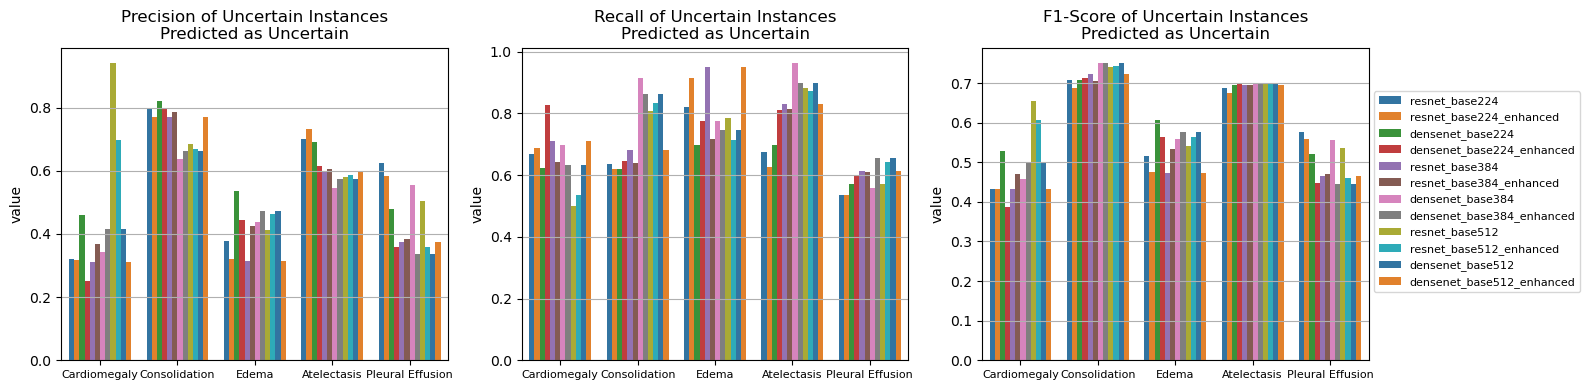

In [27]:
### Plotting TPR across models, one subplot per condition
fig,ax = plt.subplots(1,3, figsize=(16,4))
###

metric = "prec"
df_filter = (
    (results_df.results_df_name=="test_results") & \
    (results_df.metric_category=="certain_vs_uncertain") & \
    (results_df.metric==metric)
)
plot_df = results_df.loc[df_filter, :]
#
sns.barplot(data=plot_df, x="condition", y="value", hue="model_name", palette=byModel_palette, ax=ax[0])
ax[0].set_xlabel("")
ax[0].set_title("Precision of Uncertain Instances\nPredicted as Uncertain")
ax[0].xaxis.set_tick_params(labelsize=8)
ax[0].grid(axis="y")
ax[0].get_legend().remove()

metric = "recall"
df_filter = (
    (results_df.results_df_name=="test_results") & \
    (results_df.metric_category=="certain_vs_uncertain") & \
    (results_df.metric==metric)
)
plot_df = results_df.loc[df_filter, :]
#
sns.barplot(data=plot_df, x="condition", y="value", hue="model_name", palette=byModel_palette, ax=ax[1])
ax[1].set_xlabel("")
ax[1].set_title("Recall of Uncertain Instances\nPredicted as Uncertain")
ax[1].xaxis.set_tick_params(labelsize=8)
ax[1].grid(axis="y")
ax[1].get_legend().remove()

metric = "f1_score"
df_filter = (
    (results_df.results_df_name=="test_results") & \
    (results_df.metric_category=="certain_vs_uncertain") & \
    (results_df.metric==metric)
)
plot_df = results_df.loc[df_filter, :]
#
sns.barplot(data=plot_df, x="condition", y="value", hue="model_name", palette=byModel_palette, ax=ax[2])
ax[2].set_xlabel("")
ax[2].set_title("F1-Score of Uncertain Instances\nPredicted as Uncertain")
ax[2].xaxis.set_tick_params(labelsize=8)
ax[2].grid(axis="y")
ax[2].legend(loc="lower left", bbox_to_anchor=(1,0.2), fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
byModel_palette = {name:color for name,color in zip(results_dfs_names,
                                                    sns.color_palette(
                                                        palette="tab10", 
                                                        n_colors=len(results_dfs_names)
                                                    )
                                                   )
                  }
print(byModel_palette)

In [ ]:
def plot_avg_metrics(df, palette=None, n_plots_x=None, n_plots_y=None, grid=None, figsize=None):
    if n_plots_y is None: n_plots_y = int(len(df.columns))
    if figsize is None: figsize=(n_plots_y*1.5, 1.5)
        #
    fig, axes = plt.subplots(1, n_plots_y, figsize=figsize)
    for i,(ax,col) in enumerate(zip(axes.flatten(), df.columns)):
        plot_df = df[[col]].sort_values(by=col, ascending=False).reset_index().rename(columns={"index":"Row"})
        if i==0:
            sns.barplot(data=plot_df, x="Row", y=col, hue="Row", palette=palette, ax=ax, order=plot_df["Row"], width=0.75, gap=0.025, legend="brief")
        else:
            sns.barplot(data=plot_df, x="Row", y=col, hue="Row", palette=palette, ax=ax, order=plot_df["Row"], width=0.75, gap=0.025)
        sns.barplot(data=plot_df, x="Row", y=col, hue="Row", palette=palette, ax=ax, order=plot_df["Row"], width=0.75, gap=0.025)
        ax.set(ylim=(0,1), ylabel="", xlabel="", xticks="")
        ax.set_title(col, fontsize=8)
        ax.tick_params(axis='y', labelsize=6)
        if grid:
            ax.grid(axis="x")
        if i==0:
            sns.move_legend(ax, loc="lower left", bbox_to_anchor=(len(df.columns)//6,-.5), ncol=len(df.columns)//2, frameon=False, fontsize=7, title="")
    plt.subplots_adjust(wspace=0.4, hspace=0.6)
    return fig,axes

In [ ]:
### Visualize
plot_fig, plot_axes = plot_avg_metrics(avgModelStats_byClass, byModel_palette)
#
print("Average Results by Model")
avgModelStats_byClass

In [ ]:
print("Breakdown of contents for stats_byClass_byValue")
for key,values in stats_byClass_byValue.items():
    print(f"Key1: {key}")
    for key2,values2 in values.items():
        print(f"\tKey2: {key2}")

In [ ]:
### Example data
# stats_byClass_byValue["densenet_base224_enhanced"]["Stats by Class by Value"]

In [ ]:
### Example data
stats_byClass_byValue["densenet_base224_enhanced"]["Avg Stats by Value"]

In [ ]:
for i,name in enumerate(results_dfs_names):
    print(f"{i}: {name}")

In [ ]:
### View stats by training image type
name_ind = 10


output_col = results_dfs_names[name_ind]
input_df = results_dfs_data[name_ind]
#
n_plots_x = 3
n_plots_y = 2
figsize = (20,16)
#
stats_dict, stats_dict_byClass = scripts.analysis.get_metrics_byClass(input_df,
                                                                      figsize=figsize,
                                                                      **metrics_kwargs)
avg_metrics_byClass = stats_dict["Avg Stats by Class"].loc[["Avg Class Precision", 
                                                            "Avg Class Recall", 
                                                            "Avg Class F1 Score",
                                                            "Avg Class TPR", 
                                                            "Avg Class TNR", 
                                                            "Avg Class BER"],:].T
color_map = {}
plot_fig, plot_axes = scripts.analysis.plot_avg_metrics(avg_metrics_byClass, 
                                                        byClass_palette, 
                                                        n_plots_x, 
                                                        n_plots_y, 
                                                        figsize=figsize, 
                                                        grid=True)
plot_fig.suptitle(f"Average Metrics for Each Condition\n({output_col})")
plot_fig.tight_layout()
avg_metrics_byClass

In [ ]:
metrics_cols = ["Avg Class Precision", 
               "Avg Class TPR",
               "Avg Class Recall", 
               "Avg Class TNR",
               "Avg Class F1 Score",
               "Avg Class BER"]